# Benchmark on Synthetic CBN Data

Same pipeline as `benchmark_sachs.ipynb` but on synthetic data generated from a known continuous Bayesian network via `create_simple_cbn` + `generate_from_cbn`.

## DAG structure (10 nodes, 12 arcs)

```
0 -> 1,  0 -> 2,  0 -> 9
1 -> 3,  2 -> 3          (v-structure at 3)
3 -> 4
4 -> 5,  4 -> 6
5 -> 7,  6 -> 7          (v-structure at 7)
7 -> 8,  9 -> 8
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyagrum as gum
import pyagrum.lib.notebook as gnb

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from algorithms.CPCAdapter import CPCAdapter
from algorithms.CMIICAdapter import CMIICAdapter
from algorithms.MIICAdapter import MIICAdapter
from algorithms.GHCBDeuAdapter import GHCBDeuAdapter
from algorithms.NOTEARSAdapter import NOTEARSAdapter
from algorithms.LiNGAMAdapter import LiNGAMAdapter
from pipeline.Dataset import Dataset
from metrics.SHDMetric import SHDMetric
from metrics.F1ScoreMetric import F1ScoreMetric
from metrics.TPRMetric import TPRMetric
from data.generators import create_simple_cbn, generate_from_cbn
from analysis.GridSearch import GridSearch
from analysis.ParetoSelector import pareto_front, best_pareto

## 1. Generation des donnees synthetiques

In [2]:
# Build DAG: 10 nodes, 12 arcs, 2 v-structures
dag = gum.DAG()
dag.addNodes(10)
arcs = [
    (0, 1), (0, 2), (0, 9),
    (1, 3), (2, 3),          # v-structure at 3
    (3, 4),
    (4, 5), (4, 6),
    (5, 7), (6, 7),          # v-structure at 7
    (7, 8), (9, 8),
]
for tail, head in arcs:
    dag.addArc(tail, head)

var_names = [f"X{i}" for i in range(10)]
cbn = create_simple_cbn(dag, var_names=var_names, copula_correlation=0.8)
dataset, ground_truth = generate_from_cbn(cbn, n_samples=2000, seed=42)

# Add feature names to dataset
dataset = Dataset(
    dataset.data,
    golden_structure=ground_truth,
    name="synthetic_10nodes",
    feature_names=var_names,
)

print(f"Dataset: {dataset.n_samples} samples, {dataset.n_features} variables")
print(f"Ground truth: {ground_truth.cpdag.sizeArcs()} arcs, {ground_truth.cpdag.sizeEdges()} edges")

Dataset: 2000 samples, 10 variables
Ground truth: 9 arcs, 3 edges


Golden CPDAG:


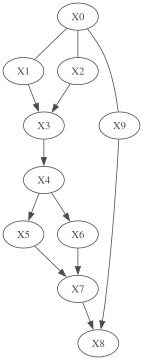

In [3]:
def cpdag_to_dot(structure, feature_names=None):
    """Convert a Structure's CPDAG to a labeled dot string."""
    mg = structure.cpdag
    lines = ["digraph {"]
    for node_id in sorted(mg.nodes()):
        label = feature_names[node_id] if feature_names else str(node_id)
        lines.append(f'  {node_id} [label="{label}"];')
    for tail, head in mg.arcs():
        lines.append(f"  {tail} -> {head};")
    for n1, n2 in mg.edges():
        lines.append(f"  {n1} -> {n2} [dir=none];")
    lines.append("}")
    return "\n".join(lines)

print("Golden CPDAG:")
gnb.showDot(cpdag_to_dot(ground_truth, var_names))

## 2. Configuration

In [4]:
metrics = [SHDMetric(), F1ScoreMetric(), TPRMetric()]
metric_names = [m.name() for m in metrics]
objectives = {"SHD": True, "F1-Score": False, "TPR": False}
pareto_objectives = {"SHD": True, "F1-Score": False}

algo_configs = [
    ("CPC v1",    CPCAdapter,      {"alpha": [0.001, 0.01, 0.05, 0.10], "max_conditioning_set_size": [2, 3, 4, 5]}, {"version": 1}),
    ("CPC2 v2",   CPCAdapter,      {"alpha": [0.001, 0.01, 0.05, 0.10], "max_conditioning_set_size": [2, 3, 4, 5]}, {"version": 2}),
    ("CMIIC v1",  CMIICAdapter,    {"alpha": [0.001, 0.01, 0.05, 0.10]}, {"version": 1}),
    ("CMIIC2 v2", CMIICAdapter,    {"alpha": [0.001, 0.01, 0.05, 0.10]}, {"version": 2}),
    ("MIIC",      MIICAdapter,     {"n_bins": [2, 3, 4, 5, 6], "discretization_method": ["quantile", "hartemink"]}, {}),
    ("GHC+BDeu",  GHCBDeuAdapter,  {"n_bins": [2, 3, 4, 5, 6], "discretization_method": ["quantile", "hartemink"]}, {}),
    ("NOTEARS",   NOTEARSAdapter,  {"lambda1": [0.01, 0.05, 0.1, 0.2, 0.5], "w_threshold": [0.1, 0.2, 0.3, 0.5]}, {}),
    ("LiNGAM",    LiNGAMAdapter,   {"measure": ["pwling"], "threshold": [0.001, 0.005, 0.01, 0.05]}, {}),
]

algo_configs_map = {name: (cls, fp) for name, cls, _, fp in algo_configs}

## 3. Grid search + visualisation par algorithme


Grid Search: CPCAdapter
  Fixed params: version=1
  Metrics: SHD, F1-Score, TPR
  Parameter combinations: 16

  [1/16] alpha=0.001, max_conditioning_set_size=2 ... SHD=8.0000, F1-Score=0.5556, TPR=1.0000
  [2/16] alpha=0.001, max_conditioning_set_size=3 ... SHD=8.0000, F1-Score=0.5000, TPR=1.0000
  [3/16] alpha=0.001, max_conditioning_set_size=4 ... SHD=8.0000, F1-Score=0.5000, TPR=1.0000
  [4/16] alpha=0.001, max_conditioning_set_size=5 ... SHD=8.0000, F1-Score=0.5000, TPR=1.0000
  [5/16] alpha=0.01, max_conditioning_set_size=2 ... SHD=11.0000, F1-Score=0.3529, TPR=1.0000
  [6/16] alpha=0.01, max_conditioning_set_size=3 ... SHD=9.0000, F1-Score=0.4000, TPR=1.0000
  [7/16] alpha=0.01, max_conditioning_set_size=4 ... SHD=9.0000, F1-Score=0.4000, TPR=1.0000
  [8/16] alpha=0.01, max_conditioning_set_size=5 ... SHD=9.0000, F1-Score=0.4000, TPR=1.0000
  [9/16] alpha=0.05, max_conditioning_set_size=2 ... SHD=13.0000, F1-Score=0.3158, TPR=1.0000
  [10/16] alpha=0.05, max_conditioning_set_siz

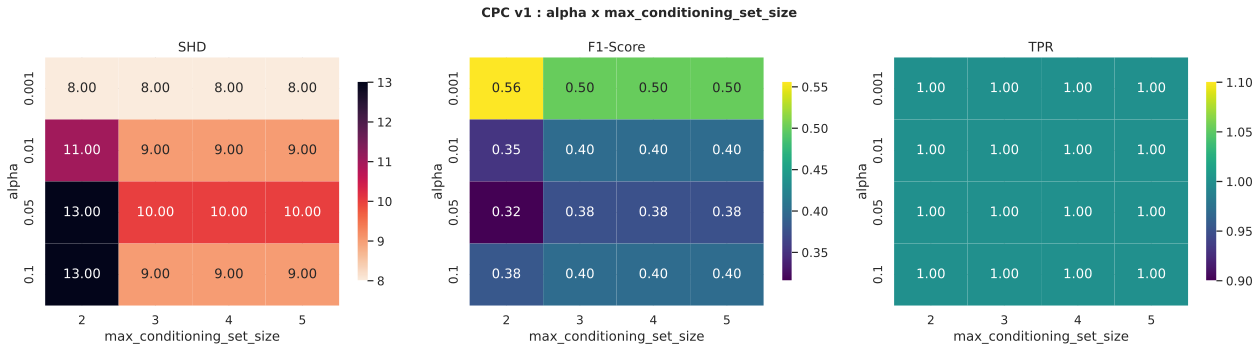

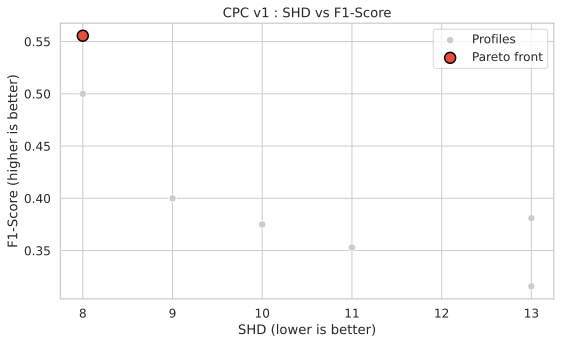


Grid Search: CPCAdapter
  Fixed params: version=2
  Metrics: SHD, F1-Score, TPR
  Parameter combinations: 16

  [1/16] alpha=0.001, max_conditioning_set_size=2 ... SHD=8.0000, F1-Score=0.5556, TPR=1.0000
  [2/16] alpha=0.001, max_conditioning_set_size=3 ... SHD=8.0000, F1-Score=0.5000, TPR=1.0000
  [3/16] alpha=0.001, max_conditioning_set_size=4 ... SHD=8.0000, F1-Score=0.5000, TPR=1.0000
  [4/16] alpha=0.001, max_conditioning_set_size=5 ... SHD=8.0000, F1-Score=0.5000, TPR=1.0000
  [5/16] alpha=0.01, max_conditioning_set_size=2 ... SHD=11.0000, F1-Score=0.3529, TPR=1.0000
  [6/16] alpha=0.01, max_conditioning_set_size=3 ... SHD=9.0000, F1-Score=0.4000, TPR=1.0000
  [7/16] alpha=0.01, max_conditioning_set_size=4 ... SHD=9.0000, F1-Score=0.4000, TPR=1.0000
  [8/16] alpha=0.01, max_conditioning_set_size=5 ... SHD=9.0000, F1-Score=0.4000, TPR=1.0000
  [9/16] alpha=0.05, max_conditioning_set_size=2 ... SHD=13.0000, F1-Score=0.3158, TPR=1.0000
  [10/16] alpha=0.05, max_conditioning_set_siz

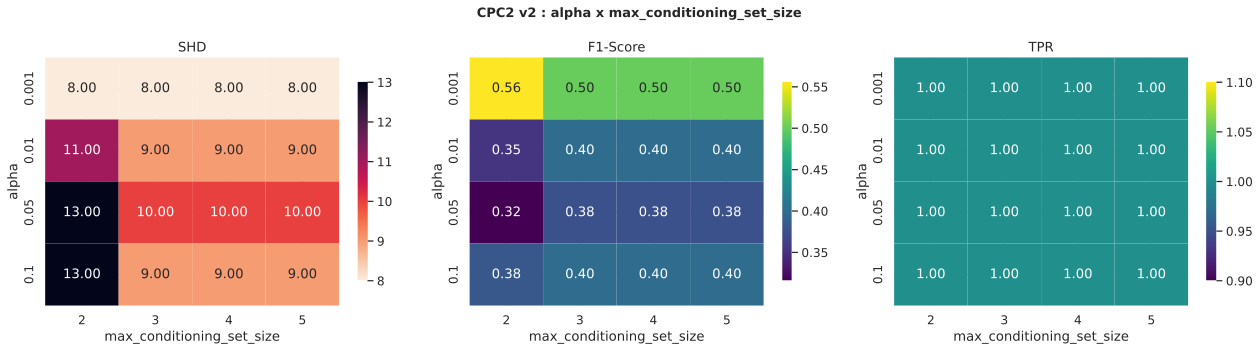

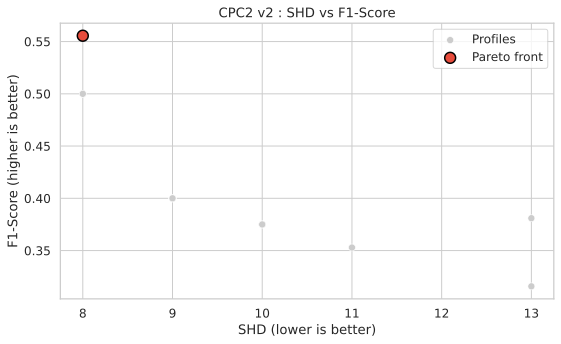


Grid Search: CMIICAdapter
  Fixed params: version=1
  Metrics: SHD, F1-Score, TPR
  Parameter combinations: 4

  [1/4] alpha=0.001 ... SHD=34.0000, F1-Score=0.1905, TPR=1.0000
  [2/4] alpha=0.01 ... SHD=11.0000, F1-Score=0.1538, TPR=1.0000
  [3/4] alpha=0.05 ... SHD=11.0000, F1-Score=0.1538, TPR=1.0000
  [4/4] alpha=0.1 ... SHD=11.0000, F1-Score=0.1538, TPR=1.0000

  Best SHD: 11.0000
    params: {'alpha': 0.01}

  Best F1-Score: 0.1905
    params: {'alpha': 0.001}

  Best TPR: 1.0000
    params: {'alpha': 0.001}




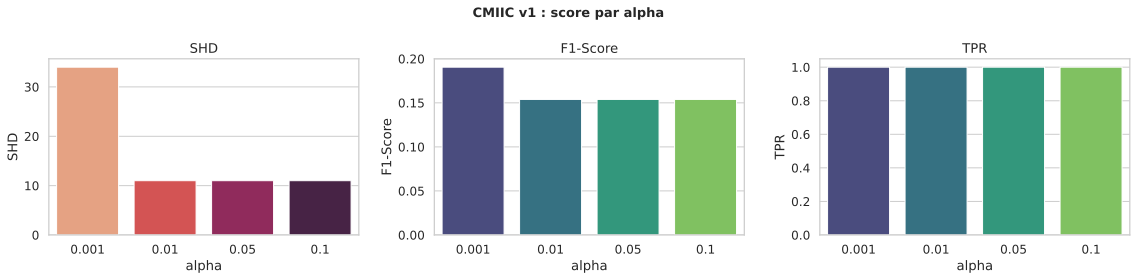

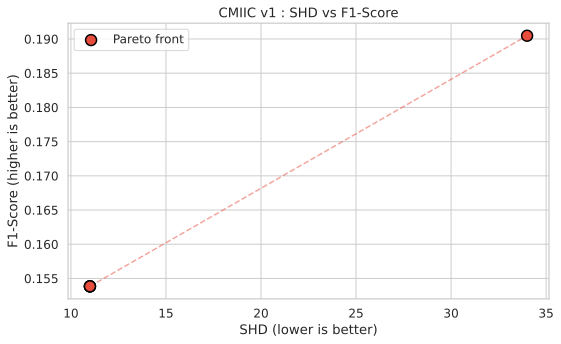


Grid Search: CMIICAdapter
  Fixed params: version=2
  Metrics: SHD, F1-Score, TPR
  Parameter combinations: 4

  [1/4] alpha=0.001 ... SHD=34.0000, F1-Score=0.1905, TPR=1.0000
  [2/4] alpha=0.01 ... SHD=10.0000, F1-Score=0.2857, TPR=1.0000
  [3/4] alpha=0.05 ... SHD=10.0000, F1-Score=0.2857, TPR=1.0000
  [4/4] alpha=0.1 ... SHD=10.0000, F1-Score=0.2857, TPR=1.0000

  Best SHD: 10.0000
    params: {'alpha': 0.01}

  Best F1-Score: 0.2857
    params: {'alpha': 0.01}

  Best TPR: 1.0000
    params: {'alpha': 0.001}




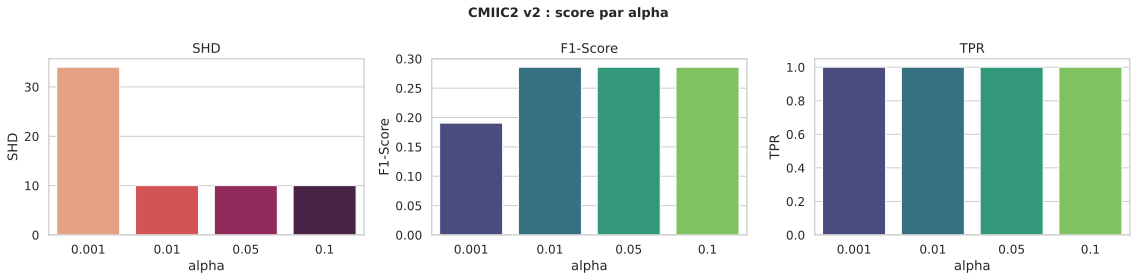

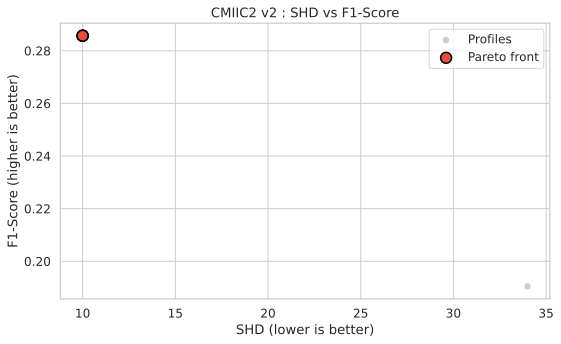


Grid Search: MIICAdapter
  Metrics: SHD, F1-Score, TPR
  Parameter combinations: 10

  [1/10] n_bins=2, discretization_method=quantile ... SHD=13.0000, F1-Score=0.3529, TPR=1.0000
  [2/10] n_bins=2, discretization_method=hartemink ... SHD=15.0000, F1-Score=0.3000, TPR=1.0000
  [3/10] n_bins=3, discretization_method=quantile ... SHD=10.0000, F1-Score=0.4000, TPR=1.0000
  [4/10] n_bins=3, discretization_method=hartemink ... SHD=10.0000, F1-Score=0.4000, TPR=1.0000
  [5/10] n_bins=4, discretization_method=quantile ... SHD=10.0000, F1-Score=0.4000, TPR=1.0000
  [6/10] n_bins=4, discretization_method=hartemink ... SHD=10.0000, F1-Score=0.4000, TPR=1.0000
  [7/10] n_bins=5, discretization_method=quantile ... SHD=12.0000, F1-Score=0.3750, TPR=0.6000
  [8/10] n_bins=5, discretization_method=hartemink ... SHD=11.0000, F1-Score=0.4000, TPR=0.7500
  [9/10] n_bins=6, discretization_method=quantile ... SHD=11.0000, F1-Score=0.4000, TPR=0.7500
  [10/10] n_bins=6, discretization_method=hartemink ...

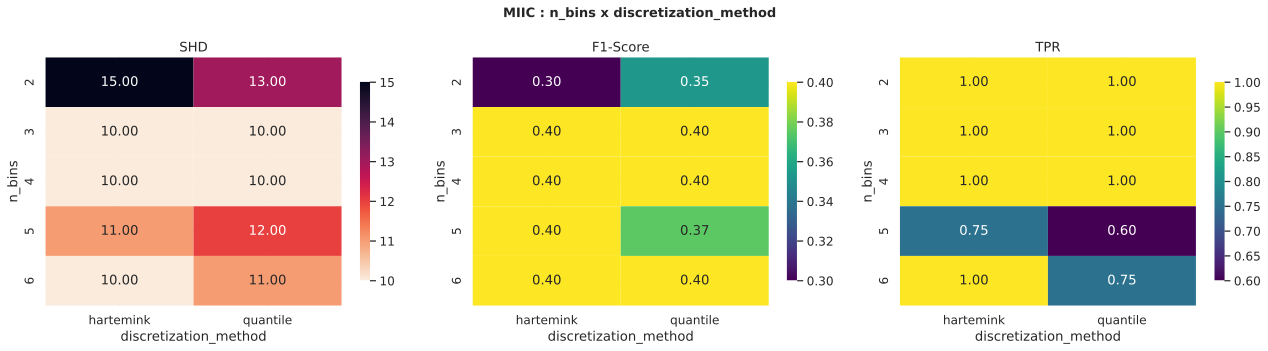

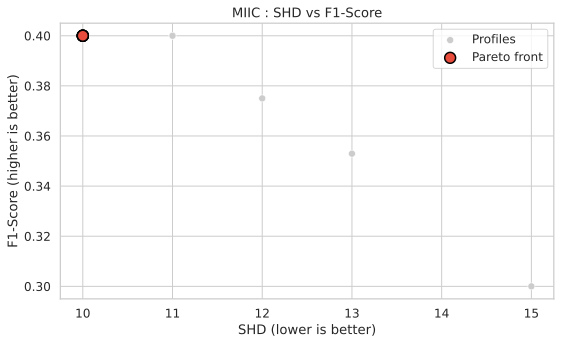


Grid Search: GHCBDeuAdapter
  Metrics: SHD, F1-Score, TPR
  Parameter combinations: 10

  [1/10] n_bins=2, discretization_method=quantile ... SHD=13.0000, F1-Score=0.4545, TPR=1.0000
  [2/10] n_bins=2, discretization_method=hartemink ... SHD=14.0000, F1-Score=0.4615, TPR=1.0000
  [3/10] n_bins=3, discretization_method=quantile ... SHD=6.0000, F1-Score=0.7000, TPR=1.0000
  [4/10] n_bins=3, discretization_method=hartemink ... SHD=7.0000, F1-Score=0.6667, TPR=1.0000
  [5/10] n_bins=4, discretization_method=quantile ... SHD=6.0000, F1-Score=0.7000, TPR=1.0000
  [6/10] n_bins=4, discretization_method=hartemink ... SHD=6.0000, F1-Score=0.7000, TPR=1.0000
  [7/10] n_bins=5, discretization_method=quantile ... SHD=8.0000, F1-Score=0.6000, TPR=0.6667
  [8/10] n_bins=5, discretization_method=hartemink ... SHD=7.0000, F1-Score=0.6316, TPR=0.7500
  [9/10] n_bins=6, discretization_method=quantile ... SHD=10.0000, F1-Score=0.3750, TPR=0.4286
  [10/10] n_bins=6, discretization_method=hartemink ... SH

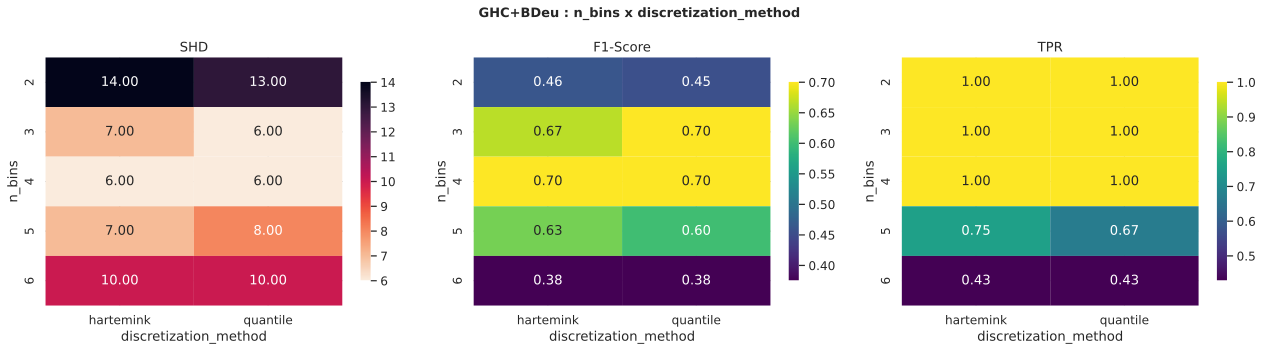

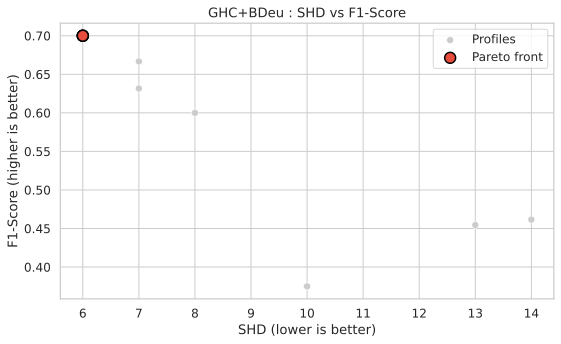


Grid Search: NOTEARSAdapter
  Metrics: SHD, F1-Score, TPR
  Parameter combinations: 20

  [1/20] lambda1=0.01, w_threshold=0.1 ... SHD=0.0000, F1-Score=1.0000, TPR=1.0000
  [2/20] lambda1=0.01, w_threshold=0.2 ... SHD=0.0000, F1-Score=1.0000, TPR=1.0000
  [3/20] lambda1=0.01, w_threshold=0.3 ... SHD=0.0000, F1-Score=1.0000, TPR=1.0000
  [4/20] lambda1=0.01, w_threshold=0.5 ... SHD=9.0000, F1-Score=0.4000, TPR=0.3333
  [5/20] lambda1=0.05, w_threshold=0.1 ... SHD=9.0000, F1-Score=0.4000, TPR=0.3750
  [6/20] lambda1=0.05, w_threshold=0.2 ... SHD=12.0000, F1-Score=0.0000, TPR=0.0000
  [7/20] lambda1=0.05, w_threshold=0.3 ... SHD=12.0000, F1-Score=0.0000, TPR=0.0000
  [8/20] lambda1=0.05, w_threshold=0.5 ... SHD=12.0000, F1-Score=0.0000, TPR=0.0000
  [9/20] lambda1=0.1, w_threshold=0.1 ... SHD=12.0000, F1-Score=0.0000, TPR=0.0000
  [10/20] lambda1=0.1, w_threshold=0.2 ... SHD=12.0000, F1-Score=0.0000, TPR=0.0000
  [11/20] lambda1=0.1, w_threshold=0.3 ... SHD=12.0000, F1-Score=0.0000, TPR=

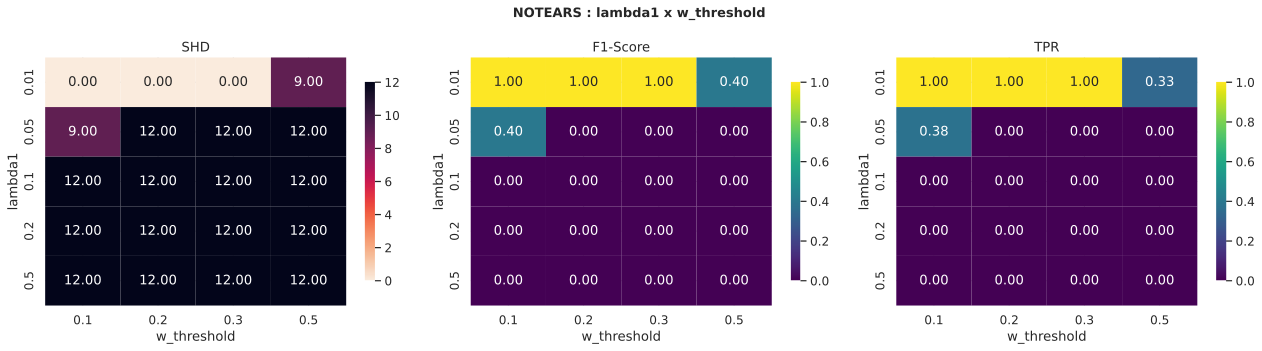

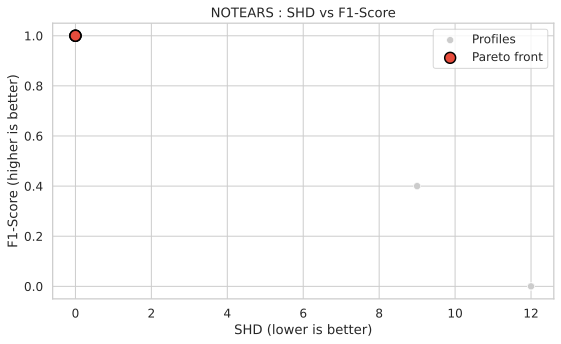


Grid Search: LiNGAMAdapter
  Metrics: SHD, F1-Score, TPR
  Parameter combinations: 4

  [1/4] measure=pwling, threshold=0.001 ... SHD=23.0000, F1-Score=0.2581, TPR=1.0000
  [2/4] measure=pwling, threshold=0.005 ... SHD=23.0000, F1-Score=0.2581, TPR=1.0000
  [3/4] measure=pwling, threshold=0.01 ... SHD=23.0000, F1-Score=0.2581, TPR=1.0000
  [4/4] measure=pwling, threshold=0.05 ... SHD=21.0000, F1-Score=0.2759, TPR=1.0000

  Best SHD: 21.0000
    params: {'measure': 'pwling', 'threshold': 0.05}

  Best F1-Score: 0.2759
    params: {'measure': 'pwling', 'threshold': 0.05}

  Best TPR: 1.0000
    params: {'measure': 'pwling', 'threshold': 0.001}




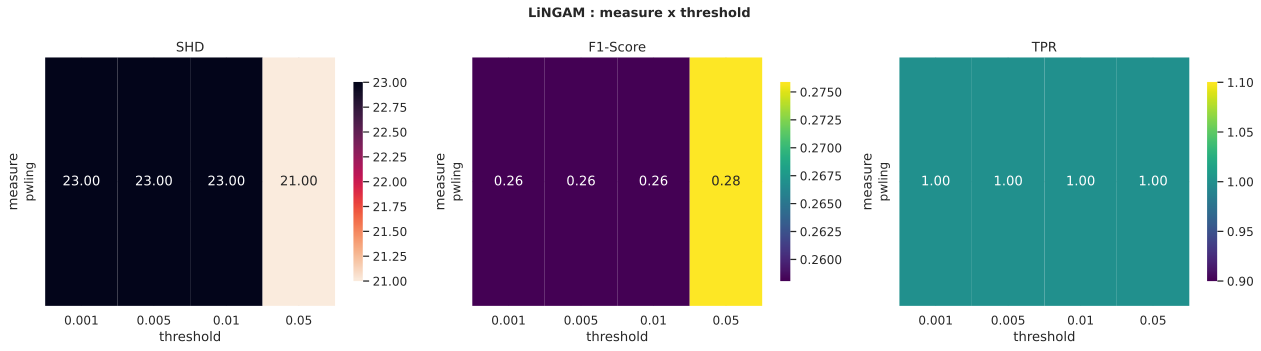

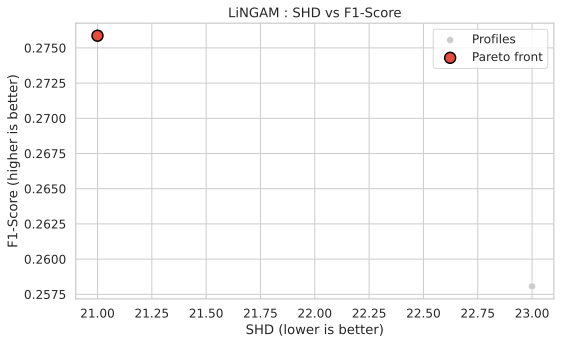

In [5]:
grid_searches = {}

for name, algo_class, param_grid, fixed_params in algo_configs:
    gs = GridSearch(
        algorithm_class=algo_class,
        param_grid=param_grid,
        dataset=dataset,
        golden_structure=ground_truth,
        metrics=metrics,
        fixed_params=fixed_params if fixed_params else None,
        objectives=objectives,
    )
    gs.run()
    grid_searches[name] = gs

    df = gs.get_results_dataframe()
    param_cols = [c for c in df.columns if c not in metric_names + ["error"]]

    # --- Bar chart (1 param) or Heatmap (2 params) per metric ---
    if len(param_cols) == 1:
        p = param_cols[0]
        df[p] = df[p].astype(str)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
        fig.suptitle(f"{name} : score par {p}", fontsize=13, fontweight="bold")
        for ax, mn, palette in zip(axes, metric_names, ["rocket_r", "viridis", "viridis"]):
            sns.barplot(data=df, x=p, y=mn, ax=ax, hue=p, palette=palette, legend=False)
            ax.set_title(mn)
        plt.tight_layout()
        plt.show()

    elif len(param_cols) == 2:
        p1, p2 = param_cols
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"{name} : {p1} x {p2}", fontsize=13, fontweight="bold")
        for ax, mn, cmap in zip(axes, metric_names, ["rocket_r", "viridis", "viridis"]):
            pivot = df.pivot_table(index=p1, columns=p2, values=mn, aggfunc="mean")
            sns.heatmap(pivot, annot=True, fmt=".2f", cmap=cmap, ax=ax, cbar_kws={"shrink": 0.8})
            ax.set_title(mn)
        plt.tight_layout()
        plt.show()

    # --- Scatter SHD vs F1 + Pareto front ---
    valid = [r for r in gs.results if "SHD" in r.scores and "F1-Score" in r.scores]
    if valid:
        front = pareto_front(gs.results, pareto_objectives)
        front_ids = {id(r) for r in front}

        scatter_df = pd.DataFrame([
            {"SHD": r.scores["SHD"], "F1-Score": r.scores["F1-Score"],
             "Pareto": "Pareto front" if id(r) in front_ids else "Profile"}
            for r in valid
        ])

        fig, ax = plt.subplots(figsize=(8, 5))
        sns.scatterplot(
            data=scatter_df[scatter_df["Pareto"] == "Profile"],
            x="SHD", y="F1-Score", color="#cccccc", s=50, ax=ax, label="Profiles"
        )
        sns.scatterplot(
            data=scatter_df[scatter_df["Pareto"] == "Pareto front"],
            x="SHD", y="F1-Score", color="#e74c3c", s=120, ax=ax,
            edgecolor="black", linewidth=1.5, label="Pareto front", zorder=5
        )
        if len(front) > 1:
            front_sorted = sorted(front, key=lambda r: r.scores["SHD"])
            ax.plot(
                [r.scores["SHD"] for r in front_sorted],
                [r.scores["F1-Score"] for r in front_sorted],
                color="#e74c3c", linestyle="--", alpha=0.5
            )
        ax.set_xlabel("SHD (lower is better)")
        ax.set_ylabel("F1-Score (higher is better)")
        ax.set_title(f"{name} : SHD vs F1-Score")
        ax.legend()
        plt.tight_layout()
        plt.show()

## 4. Tableau recapitulatif

In [6]:
summary_rows = []
for name, gs in grid_searches.items():
    row = {"Algorithm": name}
    for mn in metric_names:
        row[f"Best {mn}"] = gs.best_score(mn)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Algorithm")
summary_df

,Best SHD,Best F1-Score,Best TPR
Algorithm,,,
CPC v1,8.0,0.555556,1.0
CPC2 v2,8.0,0.555556,1.0
CMIIC v1,11.0,0.190476,1.0
CMIIC2 v2,10.0,0.285714,1.0
MIIC,10.0,0.400000,1.0
GHC+BDeu,6.0,0.700000,1.0
NOTEARS,0.0,1.000000,1.0
LiNGAM,21.0,0.275862,1.0


## 5. Selection des meilleurs profils

Pour chaque algo, on selectionne parmi les profils Pareto-optimaux (SHD vs F1) :
- **Selection A** : celui avec le plus petit SHD
- **Selection B** : celui avec le plus grand F1

In [7]:
algo_names = list(grid_searches.keys())

selection_a = {}
selection_b = {}

for name, gs in grid_searches.items():
    a = best_pareto(gs.results, pareto_objectives, rank_by="SHD", rank_lower_is_better=True)
    b = best_pareto(gs.results, pareto_objectives, rank_by="F1-Score", rank_lower_is_better=False)
    selection_a[name] = a
    selection_b[name] = b

for label, sel in [("Selection A (Pareto min SHD)", selection_a), ("Selection B (Pareto max F1)", selection_b)]:
    print(f"\n{label}:")
    for name, r in sel.items():
        if r:
            print(f"  {name:<15} SHD={r.scores['SHD']:<6.1f} F1={r.scores['F1-Score']:<6.3f} params={r.params}")
        else:
            print(f"  {name:<15} No valid result")


Selection A (Pareto min SHD):
  CPC v1          SHD=8.0    F1=0.556  params={'alpha': 0.001, 'max_conditioning_set_size': 2}
  CPC2 v2         SHD=8.0    F1=0.556  params={'alpha': 0.001, 'max_conditioning_set_size': 2}
  CMIIC v1        SHD=11.0   F1=0.154  params={'alpha': 0.01}
  CMIIC2 v2       SHD=10.0   F1=0.286  params={'alpha': 0.01}
  MIIC            SHD=10.0   F1=0.400  params={'n_bins': 3, 'discretization_method': 'quantile'}
  GHC+BDeu        SHD=6.0    F1=0.700  params={'n_bins': 3, 'discretization_method': 'quantile'}
  NOTEARS         SHD=0.0    F1=1.000  params={'lambda1': 0.01, 'w_threshold': 0.1}
  LiNGAM          SHD=21.0   F1=0.276  params={'measure': 'pwling', 'threshold': 0.05}

Selection B (Pareto max F1):
  CPC v1          SHD=8.0    F1=0.556  params={'alpha': 0.001, 'max_conditioning_set_size': 2}
  CPC2 v2         SHD=8.0    F1=0.556  params={'alpha': 0.001, 'max_conditioning_set_size': 2}
  CMIIC v1        SHD=34.0   F1=0.190  params={'alpha': 0.001}
  CMIIC

## 6. Scatter comparatif : tous les algos

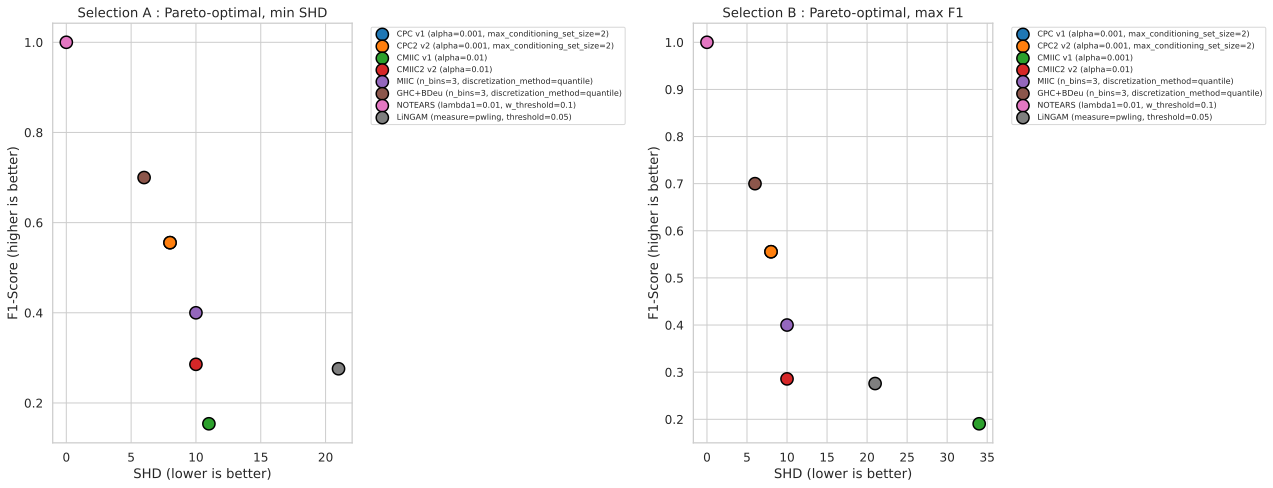

In [8]:
palette = sns.color_palette("tab10", len(algo_names))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, sel, title in zip(axes,
    [selection_a, selection_b],
    ["Selection A : Pareto-optimal, min SHD", "Selection B : Pareto-optimal, max F1"]
):
    for idx, name in enumerate(algo_names):
        r = sel[name]
        if r is None:
            continue
        params_str = ", ".join(f"{k}={v}" for k, v in r.params.items())
        ax.scatter(
            r.scores["SHD"], r.scores["F1-Score"],
            color=palette[idx], s=150, edgecolors="black", linewidths=1.5,
            label=f"{name} ({params_str})", zorder=5
        )
    ax.set_xlabel("SHD (lower is better)")
    ax.set_ylabel("F1-Score (higher is better)")
    ax.set_title(title)
    ax.legend(fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## 7. Structures apprises (CPDAGs)

In [9]:
def run_best_profiles(selection):
    """Re-run the best profile for each algo and return learned structures."""
    structures = {}
    for name in selection:
        r = selection[name]
        if r is None:
            continue
        algo_class, fixed_params = algo_configs_map[name]
        all_params = {**fixed_params, **r.params}
        algo = algo_class(**all_params)
        structures[name] = algo.learn_structure(dataset)
    return structures


def plot_pairwise_heatmaps(structures, title_prefix):
    """Plot pairwise heatmaps for each metric."""
    names = list(structures.keys())
    n = len(names)

    for metric in metrics:
        matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                if i == j:
                    matrix[i, j] = 0.0
                else:
                    matrix[i, j] = metric.compute(
                        ref=structures[names[i]],
                        test=structures[names[j]]
                    )

        lower_better = objectives.get(metric.name(), True)
        cmap = "rocket_r" if lower_better else "viridis"

        matrix_df = pd.DataFrame(matrix, index=names, columns=names)
        fig, ax = plt.subplots(figsize=(9, 7))
        sns.heatmap(matrix_df, annot=True, fmt=".2f", cmap=cmap, ax=ax,
                    cbar_kws={"shrink": 0.8}, linewidths=0.5, square=True)
        ax.set_title(f"{title_prefix} - Pairwise {metric.name()}")
        plt.tight_layout()
        plt.show()

Re-running best profiles...
  Selection A (Pareto min SHD)...
  Selection B (Pareto max F1)...
Done.

Golden CPDAG (9 arcs, 3 edges):


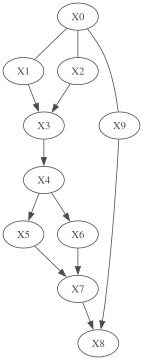

In [10]:
print("Re-running best profiles...")
print("  Selection A (Pareto min SHD)...")
structures_a = run_best_profiles(selection_a)
print("  Selection B (Pareto max F1)...")
structures_b = run_best_profiles(selection_b)
print("Done.\n")

print(f"Golden CPDAG ({ground_truth.cpdag.sizeArcs()} arcs, {ground_truth.cpdag.sizeEdges()} edges):")
gnb.showDot(cpdag_to_dot(ground_truth, var_names))

### 7a. CPDAGs - Selection A (Pareto min SHD)


CPC v1 (alpha=0.001, max_conditioning_set_size=2) — 9 arcs, 4 edges


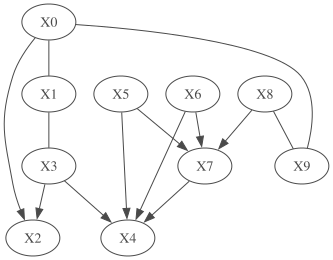


CPC2 v2 (alpha=0.001, max_conditioning_set_size=2) — 9 arcs, 4 edges


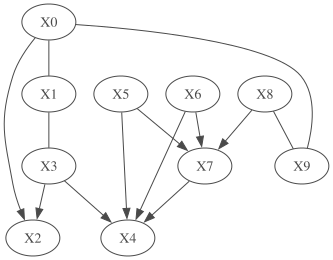


CMIIC v1 (alpha=0.01) — 6 arcs, 6 edges


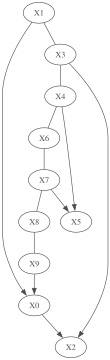


CMIIC2 v2 (alpha=0.01) — 6 arcs, 6 edges


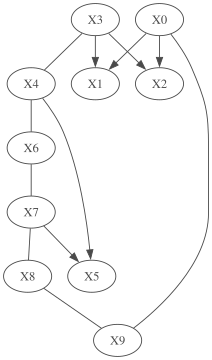


MIIC (n_bins=3, discretization_method=quantile) — 0 arcs, 12 edges


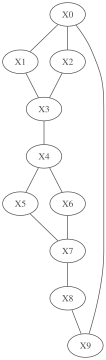


GHC+BDeu (n_bins=3, discretization_method=quantile) — 4 arcs, 9 edges


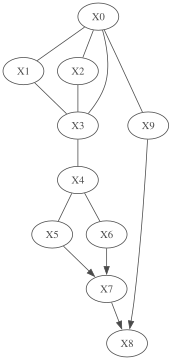


NOTEARS (lambda1=0.01, w_threshold=0.1) — 9 arcs, 3 edges


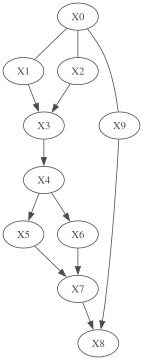


LiNGAM (measure=pwling, threshold=0.05) — 16 arcs, 9 edges


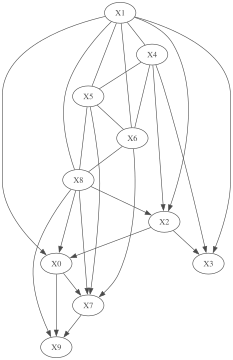

In [11]:
for name, structure in structures_a.items():
    r = selection_a[name]
    params_str = ", ".join(f"{k}={v}" for k, v in r.params.items())
    print(f"\n{name} ({params_str}) — {structure.cpdag.sizeArcs()} arcs, {structure.cpdag.sizeEdges()} edges")
    gnb.showDot(cpdag_to_dot(structure, var_names))

### 7b. CPDAGs - Selection B (Pareto max F1)


CPC v1 (alpha=0.001, max_conditioning_set_size=2) — 9 arcs, 4 edges


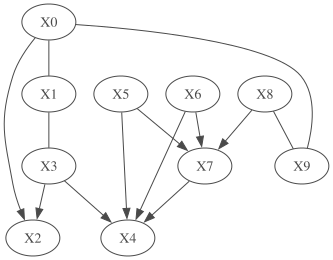


CPC2 v2 (alpha=0.001, max_conditioning_set_size=2) — 9 arcs, 4 edges


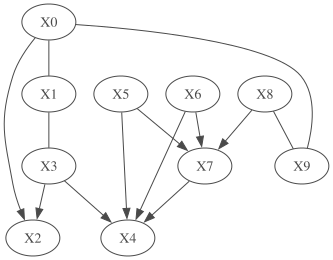


CMIIC v1 (alpha=0.001) — 33 arcs, 5 edges


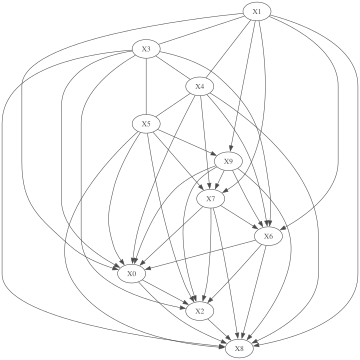


CMIIC2 v2 (alpha=0.01) — 6 arcs, 6 edges


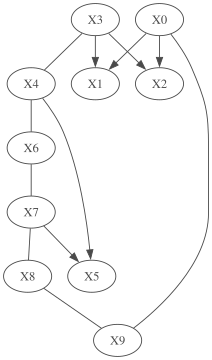


MIIC (n_bins=3, discretization_method=quantile) — 0 arcs, 12 edges


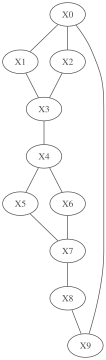


GHC+BDeu (n_bins=3, discretization_method=quantile) — 4 arcs, 9 edges


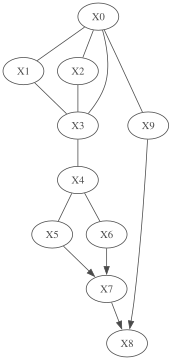


NOTEARS (lambda1=0.01, w_threshold=0.1) — 9 arcs, 3 edges


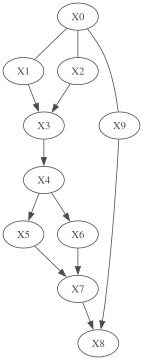


LiNGAM (measure=pwling, threshold=0.05) — 16 arcs, 9 edges


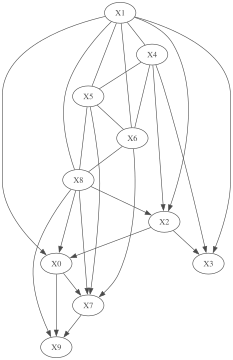

In [12]:
for name, structure in structures_b.items():
    r = selection_b[name]
    params_str = ", ".join(f"{k}={v}" for k, v in r.params.items())
    print(f"\n{name} ({params_str}) — {structure.cpdag.sizeArcs()} arcs, {structure.cpdag.sizeEdges()} edges")
    gnb.showDot(cpdag_to_dot(structure, var_names))

## 8. Heatmaps pairwise

### 8a. Pairwise - Selection A (Pareto min SHD)

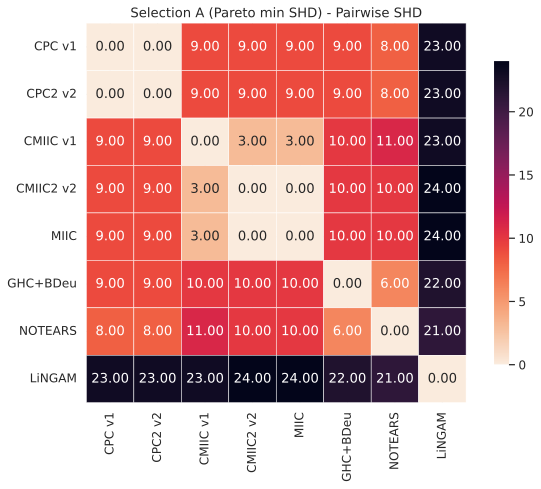

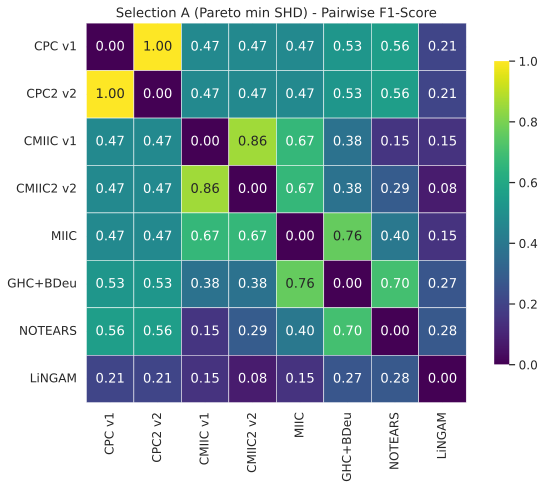

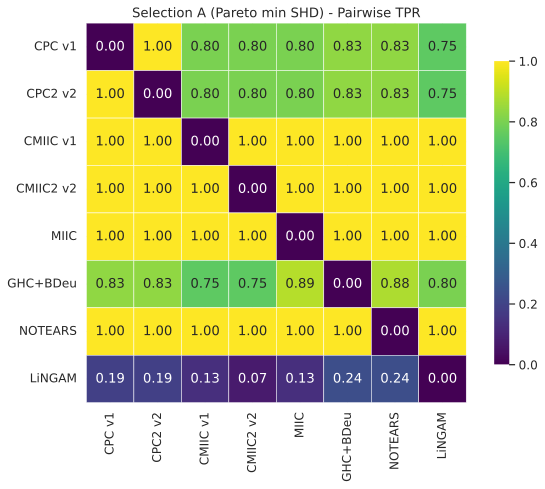

In [13]:
plot_pairwise_heatmaps(structures_a, "Selection A (Pareto min SHD)")

### 8b. Pairwise - Selection B (Pareto max F1)

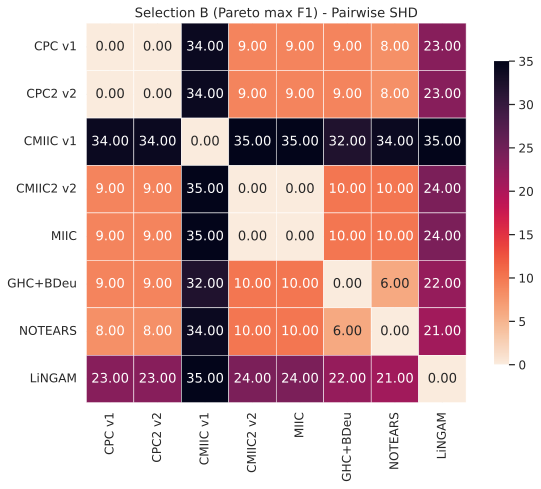

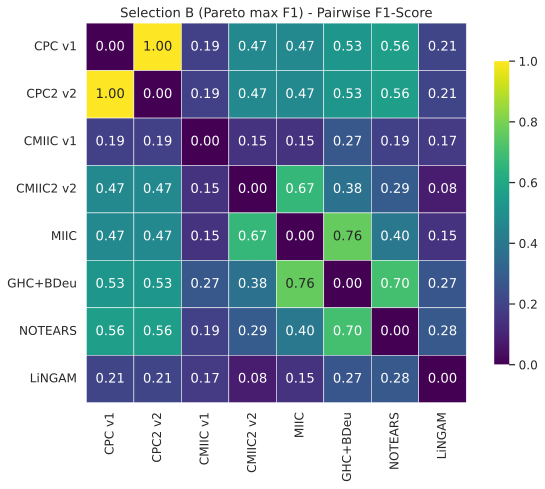

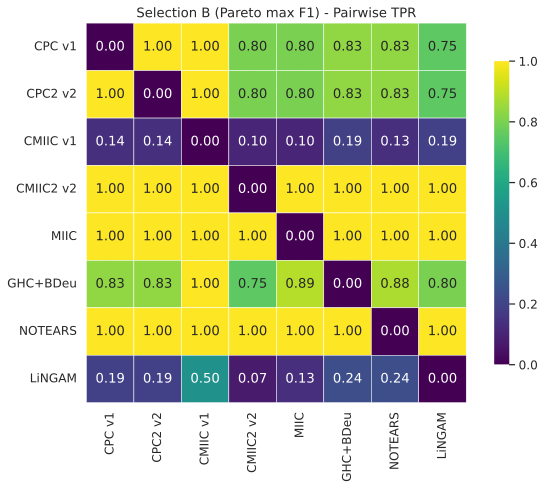

In [14]:
plot_pairwise_heatmaps(structures_b, "Selection B (Pareto max F1)")